# ⏱️ Preprocessing Time Benchmark

**Tujuan:** Mengukur waktu eksekusi setiap metode preprocessing secara individu,
menggunakan berbagai ukuran sample untuk melihat scaling behavior.

## Metode yang Di-benchmark
1. `normalize_repetitive_chars` — normalisasi karakter berulang
2. `normalize_slang` — normalisasi slang (kamus alay)
3. `emoji_to_text` — konversi emoji ke teks
4. `tokenize` — tokenisasi NLTK `word_tokenize`
5. `remove_stopwords` — hapus stopwords
6. `pos_tag` — POS tagging rule-based
7. `stem` — stemming Sastrawi
8. `stem` — stemming Sastrawi
9. `handle_negation` — penanganan negasi
10. `extract_emotion_features` — ekstraksi fitur emosi
11. `full_pipeline` — seluruh pipeline end-to-end

In [1]:
import pandas as pd
import numpy as np
import re
import time
import itertools
import ssl
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import emoji
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from collections import OrderedDict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from scipy.sparse import hstack
from sklearn.metrics import accuracy_score, f1_score

ssl._create_default_https_context = ssl._create_unverified_context
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

True

### Load Data

In [2]:
df = pd.read_csv("PRDECT-ID Dataset.csv")
df["text"] = df["Customer Review"].fillna("")

print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nSentiment distribution:\n{df['Sentiment'].value_counts()}")
print(f"\nEmotion distribution:\n{df['Emotion'].value_counts()}")

Total rows: 5400
Columns: ['Category', 'Product Name', 'Location', 'Price', 'Overall Rating', 'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review', 'Sentiment', 'Emotion', 'text']

Sentiment distribution:
Sentiment
Negative    2821
Positive    2579
Name: count, dtype: int64

Emotion distribution:
Emotion
Happy      1770
Sadness    1202
Fear        920
Love        809
Anger       699
Name: count, dtype: int64


### Load Kamus Alay — Colloquial Indonesian Lexicon

In [3]:
kamus_df = pd.read_csv("colloquial-indonesian-lexicon.csv")
kamus_valid = kamus_df[kamus_df["In-dictionary"] == 1]

slang_dict = {}
for _, row in kamus_valid.iterrows():
    slang = str(row["slang"]).strip().lower()
    formal = str(row["formal"]).strip().lower()
    if slang in slang_dict:
        if len(formal) < len(slang_dict[slang]):
            slang_dict[slang] = formal
    else:
        slang_dict[slang] = formal

print(f"Total entri kamus: {len(kamus_df)}")
print(f"Entri valid (In-dictionary=1): {len(kamus_valid)}")
print(f"Unique slang entries: {len(slang_dict)}")

Total entri kamus: 15006
Entri valid (In-dictionary=1): 13722
Unique slang entries: 3451


In [4]:
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()
print("Sastrawi stemmer siap")

Sastrawi stemmer siap


### Preprocessing Functions

Semua fungsi identik dengan yang digunakan di notebook `preprocessing_with_vectorize.ipynb`.

In [5]:
def normalize_repetitive_chars(text: str) -> str:
    text = re.sub(r"(a)\1{2,}", "a", text)
    text = re.sub(r"(i)\1{2,}", "i", text)
    text = re.sub(r"(u)\1{2,}", "u", text)
    text = re.sub(r"(e)\1{2,}", "e", text)
    text = re.sub(r"(o)\1{2,}", "o", text)
    text = re.sub(r"([^aiueo])\1{2,}", r"\1", text)
    return text


def normalize_slang(text: str, slang_dict: dict) -> str:
    words = text.split()
    normalized = []
    for w in words:
        w_lower = w.lower()
        if w_lower in slang_dict:
            normalized.append(slang_dict[w_lower])
        elif w_lower.rstrip(".,!?;:") in slang_dict:
            punct = w[len(w_lower.rstrip(".,!?;:")):]
            normalized.append(slang_dict[w_lower.rstrip(".,!?;:")] + punct)
        else:
            normalized.append(w)
    return " ".join(normalized)


def tokenize(text: str) -> list:
    return word_tokenize(text)


def remove_stopwords(tokens: list) -> list:
    stop_words = set(stopwords.words('indonesian'))
    return [t for t in tokens if t.lower() not in stop_words]


def pos_tag(tokens: list) -> list:
    konjungsi = {'dan', 'atau', 'tetapi', 'namun', 'sedangkan', 'serta',
                 'karena', 'sehingga', 'maka', 'lalu', 'kemudian',
                 'setelah', 'sebelum', 'ketika', 'sementara', 'walaupun',
                 'meskipun', 'jika', 'kalau', 'apabila', 'bahwa'}
    preposisi = {'di', 'ke', 'dari', 'pada', 'dengan', 'untuk', 'bagi',
                 'oleh', 'tentang', 'seperti', 'sebagai', 'tanpa', 'dalam',
                 'antara', 'menurut', 'sampai', 'hingga'}
    hasil = []
    for token in tokens:
        t = token.lower()
        if re.match(r'^[.,!?;:()\[\]{}"\'\-]$', token):
            hasil.append((token, 'PUNCT'))
        elif re.match(r'^[0-9,.\-]+$', token):
            hasil.append((token, 'NUM'))
        elif t in konjungsi:
            hasil.append((token, 'CONJ'))
        elif t in preposisi:
            hasil.append((token, 'ADP'))
        elif re.match(r'^(me|men|meng|meny|mem|di|ber|bel|ter|per)', t):
            hasil.append((token, 'VERB'))
        elif re.match(r'^(pe|pen|pem|peng|ke)', t) or t.endswith('an') or t.endswith('kan'):
            hasil.append((token, 'NOUN'))
        elif t.endswith('i'):
            hasil.append((token, 'VERB'))
        else:
            hasil.append((token, 'NOUN'))
    return hasil


def stem(tokens: list, stemmer) -> list:
    return [stemmer.stem(t) for t in tokens]


def emoji_to_text(text: str) -> str:
    return emoji.demojize(text, language='id')


def handle_negation(tokens: list, neg_words: set = None) -> list:
    if neg_words is None:
        neg_words = {
            "tidak", "bukan", "belum", "tak", "ngga",
            "gak", "ga", "tdk", "enggak", "nggak",
            "kagak", "ndak", "ngg"
        }
    result = []
    negate = False
    for w in tokens:
        w_clean = w.lower().strip(".,!?")
        if w_clean in neg_words:
            result.append(w)
            negate = True
        elif negate:
            result.append("NEG_" + w)
            negate = False
        else:
            result.append(w)
    return result


def extract_emotion_features(series: pd.Series) -> pd.DataFrame:
    features = pd.DataFrame(index=series.index)
    features["n_exclamation"] = series.apply(lambda x: x.count("!"))
    features["n_question"] = series.apply(lambda x: x.count("?"))
    features["n_allcaps"] = series.apply(
        lambda x: sum(1 for w in str(x).split() if w.isupper() and len(w) > 2)
    )
    features["n_ellipsis"] = series.apply(lambda x: x.count(".."))
    features["max_char_repeat"] = series.apply(
        lambda x: max(
            (len(list(g)) for _, g in itertools.groupby(str(x).lower())),
            default=0,
        )
    )
    return features


def full_pipeline(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return text
    t = text
    t = normalize_repetitive_chars(t)
    t = normalize_slang(t, slang_dict)
    t = emoji_to_text(t)
    tokens = tokenize(t)
    tokens = remove_stopwords(tokens)
    pos_tags = pos_tag(tokens)
    tokens = stem(tokens, stemmer)
    tokens = handle_negation(tokens)
    return " ".join(tokens)

### Siapkan Sample untuk Benchmark

Kita ambil beberapa ukuran sample untuk melihat scaling setiap metode: 100, 500, 1000, dan seluruh dataset (5400).

In [6]:
sample_sizes = [100, 500, 1000, len(df)]
samples = {}
for n in sample_sizes:
    samples[n] = df["text"].iloc[:n].copy()
    print(f"Sample size {n:>5}: prepared")

# Pre-tokenize untuk metode yang bekerja pada token list
# (supaya timing token-level methods tidak termasuk waktu tokenisasi)
tokenized_samples = {}
for n in sample_sizes:
    tokenized_samples[n] = [word_tokenize(t) for t in samples[n]]
    print(f"Tokenized sample size {n:>5}: prepared")

# Pre-compute POS tags untuk lemmatize benchmark
pos_tagged_samples = {}
for n in sample_sizes:
    pos_tagged_samples[n] = [pos_tag(tokens) for tokens in tokenized_samples[n]]
    print(f"POS-tagged sample size {n:>5}: prepared")

Sample size   100: prepared
Sample size   500: prepared
Sample size  1000: prepared
Sample size  5400: prepared
Tokenized sample size   100: prepared
Tokenized sample size   500: prepared
Tokenized sample size  1000: prepared
Tokenized sample size  5400: prepared
POS-tagged sample size   100: prepared
POS-tagged sample size   500: prepared
POS-tagged sample size  1000: prepared
POS-tagged sample size  5400: prepared


## ⏱️ Benchmark Execution Time

Setiap metode dijalankan beberapa kali (3 repeat) dan diambil nilai minimum untuk mengurangi noise.

In [7]:
def time_method(method_name: str, fn, input_data, repeat: int = 3):
    """Ukur waktu eksekusi fn(input_data) dalam detik, ambil minimum dari `repeat` kali."""
    times = []
    for _ in range(repeat):
        start = time.perf_counter()
        fn(input_data)
        end = time.perf_counter()
        times.append(end - start)
    return min(times)


results = []

for n in sample_sizes:
    sample = samples[n]
    tokenized = tokenized_samples[n]
    pos_tagged = pos_tagged_samples[n]
    n_docs = len(sample)

    # 1. normalize_repetitive_chars
    t = time_method("normalize_repetitive_chars",
                    lambda data: [normalize_repetitive_chars(t) for t in data],
                    sample)
    results.append(("normalize_repetitive_chars", n_docs, t, t / n_docs))
    print(f"normalize_repetitive_chars  | n={n_docs:>5} | {t:.4f}s | {t/n_docs*1000:.3f}ms/doc")

    # 2. normalize_slang
    t = time_method("normalize_slang",
                    lambda data: [normalize_slang(t, slang_dict) for t in data],
                    sample)
    results.append(("normalize_slang", n_docs, t, t / n_docs))
    print(f"normalize_slang            | n={n_docs:>5} | {t:.4f}s | {t/n_docs*1000:.3f}ms/doc")

    # 3. emoji_to_text
    t = time_method("emoji_to_text",
                    lambda data: [emoji_to_text(t) for t in data],
                    sample)
    results.append(("emoji_to_text", n_docs, t, t / n_docs))
    print(f"emoji_to_text             | n={n_docs:>5} | {t:.4f}s | {t/n_docs*1000:.3f}ms/doc")

    # 4. tokenize
    t = time_method("tokenize",
                    lambda data: [word_tokenize(t) for t in data],
                    sample)
    results.append(("tokenize", n_docs, t, t / n_docs))
    print(f"tokenize                  | n={n_docs:>5} | {t:.4f}s | {t/n_docs*1000:.3f}ms/doc")

    # 5. remove_stopwords
    t = time_method("remove_stopwords",
                    lambda data: [remove_stopwords(tokens) for tokens in data],
                    tokenized)
    results.append(("remove_stopwords", n_docs, t, t / n_docs))
    print(f"remove_stopwords          | n={n_docs:>5} | {t:.4f}s | {t/n_docs*1000:.3f}ms/doc")

    # 6. pos_tag
    t = time_method("pos_tag",
                    lambda data: [pos_tag(tokens) for tokens in data],
                    tokenized)
    results.append(("pos_tag", n_docs, t, t / n_docs))
    print(f"pos_tag                   | n={n_docs:>5} | {t:.4f}s | {t/n_docs*1000:.3f}ms/doc")

    # 8. stem
    t = time_method("stem",
                    lambda data: [stem(tokens, stemmer) for tokens in data],
                    tokenized)
    results.append(("stem", n_docs, t, t / n_docs))
    print(f"stem                      | n={n_docs:>5} | {t:.4f}s | {t/n_docs*1000:.3f}ms/doc")

    # 9. handle_negation
    t = time_method("handle_negation",
                    lambda data: [handle_negation(tokens) for tokens in data],
                    tokenized)
    results.append(("handle_negation", n_docs, t, t / n_docs))
    print(f"handle_negation           | n={n_docs:>5} | {t:.4f}s | {t/n_docs*1000:.3f}ms/doc")

    # 10. extract_emotion_features
    t = time_method("extract_emotion_features",
                    lambda data: extract_emotion_features(data),
                    sample)
    results.append(("extract_emotion_features", n_docs, t, t / n_docs))
    print(f"extract_emotion_features  | n={n_docs:>5} | {t:.4f}s | {t/n_docs*1000:.3f}ms/doc")

    # 11. full_pipeline
    t = time_method("full_pipeline",
                    lambda data: [full_pipeline(t) for t in data],
                    sample)
    results.append(("full_pipeline", n_docs, t, t / n_docs))
    print(f"full_pipeline             | n={n_docs:>5} | {t:.4f}s | {t/n_docs*1000:.3f}ms/doc")

# Build results DataFrame
cols = ["method", "n_docs", "total_time_s", "avg_time_ms_per_doc"]
results_df = pd.DataFrame(results, columns=cols)
results_df["avg_time_ms_per_doc"] = (results_df["avg_time_ms_per_doc"] * 1000).round(3)
results_df["total_time_s"] = results_df["total_time_s"].round(4)

normalize_repetitive_chars  | n=  100 | 0.0010s | 0.010ms/doc
normalize_slang            | n=  100 | 0.0004s | 0.004ms/doc
emoji_to_text             | n=  100 | 0.0053s | 0.053ms/doc
tokenize                  | n=  100 | 0.0111s | 0.111ms/doc
remove_stopwords          | n=  100 | 0.0370s | 0.370ms/doc
pos_tag                   | n=  100 | 0.0029s | 0.029ms/doc
stem                      | n=  100 | 0.0062s | 0.062ms/doc
handle_negation           | n=  100 | 0.0003s | 0.003ms/doc
extract_emotion_features  | n=  100 | 0.0036s | 0.036ms/doc
full_pipeline             | n=  100 | 0.0656s | 0.656ms/doc
normalize_repetitive_chars  | n=  500 | 0.0048s | 0.010ms/doc
normalize_slang            | n=  500 | 0.0021s | 0.004ms/doc
emoji_to_text             | n=  500 | 0.0287s | 0.057ms/doc
tokenize                  | n=  500 | 0.0647s | 0.129ms/doc
remove_stopwords          | n=  500 | 0.1766s | 0.353ms/doc
pos_tag                   | n=  500 | 0.0171s | 0.034ms/doc
stem                      | n=  50

In [8]:
np.random.seed(42)
sample_sizes_small = [1, 2, 3, 4, 5]
print("=" * 70)
print("RANDOM SAMPLING BENCHMARK (n=1 to 5)")
print("=" * 70)
for n in sample_sizes_small:    
    idx = np.random.choice(len(df), size=n, replace=False)    
    sample = df["text"].iloc[idx].copy()    
    tokenized = [word_tokenize(t) for t in sample]    
    pos_tagged = [pos_tag(tokens) for tokens in tokenized]    
    n_docs = len(sample)    
    t = time_method("normalize_repetitive_chars",                    
                    lambda data: [normalize_repetitive_chars(t) for t in data],                    
                    sample)    
    print(f"normalize_repetitive_chars  | n={n_docs:>5} | {t:.4f}s | {t/n_docs*1000:.3f}ms/doc")    
    t = time_method("normalize_slang",                    
                    lambda data: [normalize_slang(t, slang_dict) for t in data],                    
                    sample)    
    print(f"normalize_slang            | n={n_docs:>5} | {t:.4f}s | {t/n_docs*1000:.3f}ms/doc")    
    t = time_method("emoji_to_text",                    
                    lambda data: [emoji_to_text(t) for t in data],                    
                    sample)    
    print(f"emoji_to_text             | n={n_docs:>5} | {t:.4f}s | {t/n_docs*1000:.3f}ms/doc")    
    t = time_method("tokenize",                    
                    lambda data: [word_tokenize(t) for t in data],                    
                    sample)    
    print(f"tokenize                  | n={n_docs:>5} | {t:.4f}s | {t/n_docs*1000:.3f}ms/doc")    
    t = time_method("remove_stopwords",                    
                    lambda data: [remove_stopwords(tokens) for tokens in data],                    
                    tokenized)    
    print(f"remove_stopwords          | n={n_docs:>5} | {t:.4f}s | {t/n_docs*1000:.3f}ms/doc")    
    t = time_method("pos_tag",                    lambda data: [pos_tag(tokens) for tokens in data],                    
                    tokenized)    
    print(f"pos_tag                   | n={n_docs:>5} | {t:.4f}s | {t/n_docs*1000:.3f}ms/doc")    
    t = time_method("stem",                    lambda data: [stem(tokens, stemmer) for tokens in data],                    
                    tokenized)    
    print(f"stem                      | n={n_docs:>5} | {t:.4f}s | {t/n_docs*1000:.3f}ms/doc")    
    t = time_method("handle_negation",                    lambda data: [handle_negation(tokens) for tokens in data],                    
                    tokenized)    
    print(f"handle_negation           | n={n_docs:>5} | {t:.4f}s | {t/n_docs*1000:.3f}ms/doc")    
    t = time_method("extract_emotion_features",                    
                    lambda data: extract_emotion_features(data),                    
                    sample)    
    print(f"extract_emotion_features  | n={n_docs:>5} | {t:.4f}s | {t/n_docs*1000:.3f}ms/doc")    
    t = time_method("full_pipeline",                    
                    lambda data: [full_pipeline(t) for t in data],                    sample)    
    print(f"full_pipeline             | n={n_docs:>5} | {t:.4f}s | {t/n_docs*1000:.3f}ms/doc")    
    print()

RANDOM SAMPLING BENCHMARK (n=1 to 5)
normalize_repetitive_chars  | n=    1 | 0.0000s | 0.010ms/doc
normalize_slang            | n=    1 | 0.0000s | 0.005ms/doc
emoji_to_text             | n=    1 | 0.0000s | 0.016ms/doc
tokenize                  | n=    1 | 0.0000s | 0.043ms/doc
remove_stopwords          | n=    1 | 0.0004s | 0.443ms/doc
pos_tag                   | n=    1 | 0.0000s | 0.007ms/doc
stem                      | n=    1 | 0.0000s | 0.013ms/doc
handle_negation           | n=    1 | 0.0000s | 0.001ms/doc
extract_emotion_features  | n=    1 | 0.0019s | 1.852ms/doc
full_pipeline             | n=    1 | 0.0006s | 0.558ms/doc

normalize_repetitive_chars  | n=    2 | 0.0000s | 0.015ms/doc
normalize_slang            | n=    2 | 0.0000s | 0.007ms/doc
emoji_to_text             | n=    2 | 0.0001s | 0.065ms/doc
tokenize                  | n=    2 | 0.0001s | 0.068ms/doc
remove_stopwords          | n=    2 | 0.0008s | 0.418ms/doc
pos_tag                   | n=    2 | 0.0001s | 0.034ms/

## 📊 Hasil Benchmark

In [9]:
# Pivot table: baris = metode, kolom = sample size, isi = avg ms/doc
pivot_ms = results_df.pivot_table(
    index="method", columns="n_docs", values="avg_time_ms_per_doc"
)
pivot_ms.columns = [f"n={c}" for c in pivot_ms.columns]
pivot_ms = pivot_ms.sort_values(pivot_ms.columns[-1], ascending=False)

print("=== Average Time per Document (ms) ===")
display(pivot_ms.style.background_gradient(cmap="YlOrRd", axis=None).format("{:.3f}"))

print("\n=== Total Time (s) ===")
pivot_total = results_df.pivot_table(
    index="method", columns="n_docs", values="total_time_s"
)
pivot_total.columns = [f"n={c}" for c in pivot_total.columns]
pivot_total = pivot_total.sort_values(pivot_total.columns[-1], ascending=False)
display(pivot_total.style.background_gradient(cmap="YlOrRd", axis=None).format("{:.4f}"))

=== Average Time per Document (ms) ===


,n=100,n=500,n=1000,n=5400
method,,,,
full_pipeline,0.656,0.768,0.784,0.703
remove_stopwords,0.370,0.353,0.425,0.416
tokenize,0.111,0.129,0.138,0.126
stem,0.062,0.077,0.069,0.075
emoji_to_text,0.053,0.057,0.056,0.056
pos_tag,0.029,0.034,0.034,0.033
extract_emotion_features,0.036,0.026,0.025,0.021
normalize_repetitive_chars,0.010,0.010,0.009,0.010
normalize_slang,0.004,0.004,0.005,0.004



=== Total Time (s) ===


,n=100,n=500,n=1000,n=5400
method,,,,
full_pipeline,0.0656,0.3839,0.7839,3.7967
remove_stopwords,0.0370,0.1766,0.4250,2.2468
tokenize,0.0111,0.0647,0.1380,0.6829
stem,0.0062,0.0384,0.0693,0.4024
emoji_to_text,0.0053,0.0287,0.0565,0.3000
pos_tag,0.0029,0.0171,0.0344,0.1801
extract_emotion_features,0.0036,0.0132,0.0254,0.1123
normalize_repetitive_chars,0.0010,0.0048,0.0095,0.0533
normalize_slang,0.0004,0.0021,0.0045,0.0236


## 📈 Visualisasi

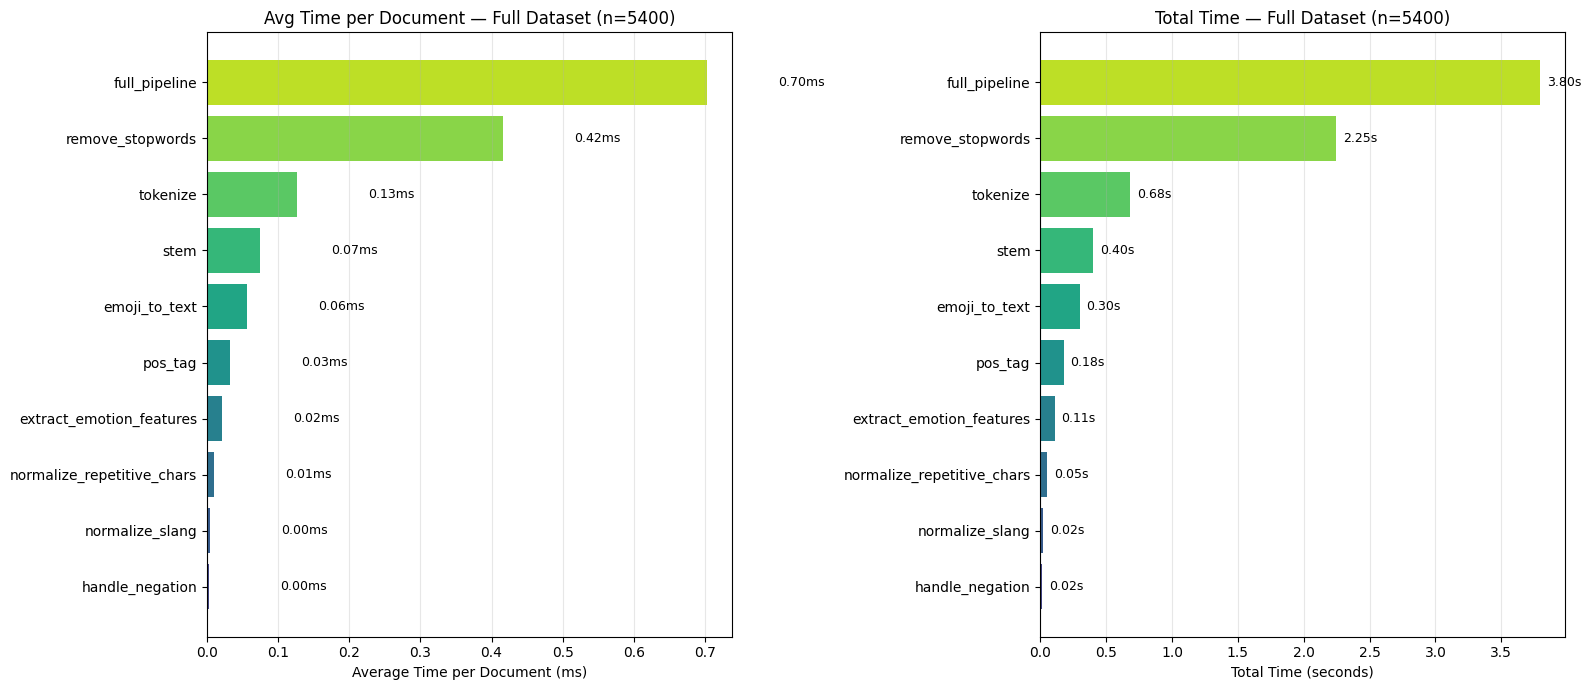

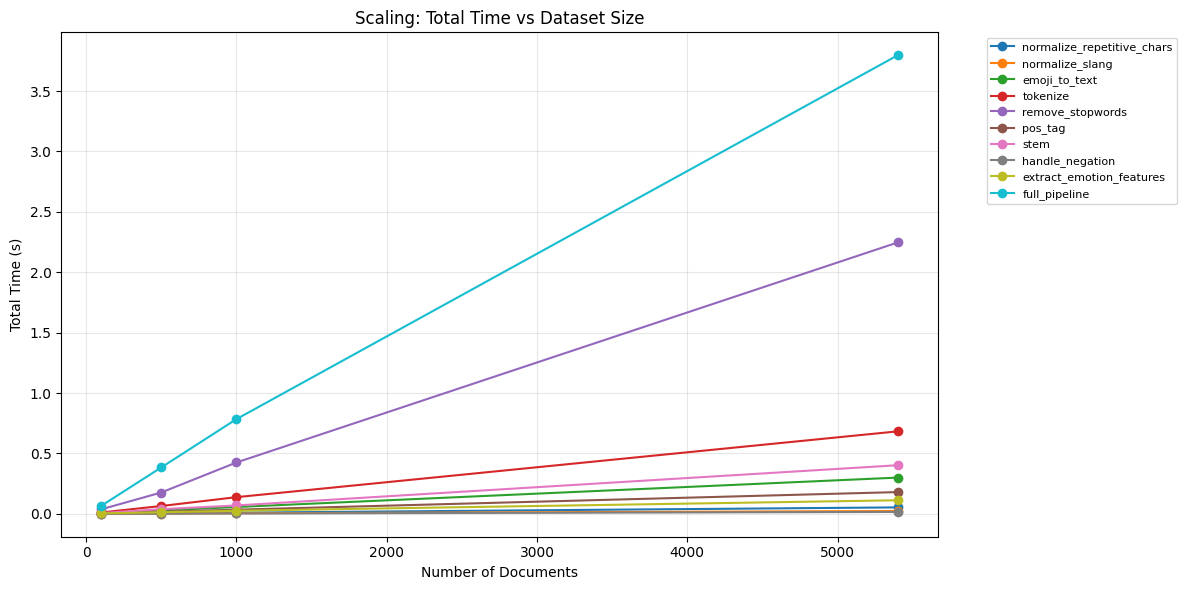

In [10]:
import matplotlib.pyplot as plt

# Plot: avg ms per doc untuk sample terbesar
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Bar chart: avg ms/doc untuk full dataset
full_idx = results_df["n_docs"] == len(df)
full_data = results_df[full_idx].sort_values("avg_time_ms_per_doc", ascending=True)

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(full_data)))
axes[0].barh(full_data["method"], full_data["avg_time_ms_per_doc"], color=colors)
axes[0].set_xlabel("Average Time per Document (ms)")
axes[0].set_title(f"Avg Time per Document — Full Dataset (n={len(df)})")
axes[0].grid(axis="x", alpha=0.3)

# Add value labels
for i, v in enumerate(full_data["avg_time_ms_per_doc"]):
    axes[0].text(v + 0.1, i, f"{v:.2f}ms", va="center", fontsize=9)

# Bar chart: total time untuk full dataset
axes[1].barh(full_data["method"], full_data["total_time_s"], color=colors)
axes[1].set_xlabel("Total Time (seconds)")
axes[1].set_title(f"Total Time — Full Dataset (n={len(df)})")
axes[1].grid(axis="x", alpha=0.3)

for i, v in enumerate(full_data["total_time_s"]):
    axes[1].text(v + 0.05, i, f"{v:.2f}s", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# Plot scaling: total time vs sample size untuk setiap metode
fig2, ax2 = plt.subplots(figsize=(12, 6))
for method in results_df["method"].unique():
    mdata = results_df[results_df["method"] == method]
    ax2.plot(mdata["n_docs"], mdata["total_time_s"], marker="o", label=method)

ax2.set_xlabel("Number of Documents")
ax2.set_ylabel("Total Time (s)")
ax2.set_title("Scaling: Total Time vs Dataset Size")
ax2.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 🔍 Analisis

- Metode dengan waktu **tercepat** biasanya adalah operasi string sederhana (regex, split).
- Metode dengan waktu **terlama** biasanya melibatkan Sastrawi (stemming/lemmatize) atau NLTK tokenizer.
- `full_pipeline` menunjukkan total kumulatif semua langkah.
- Perhatikan scaling: metode O(n) vs yang memiliki overhead per-doc tinggi.

In [ ]:
# Ranking metode berdasarkan avg ms/doc untuk full dataset
print("\n=== Ranking (Fastest → Slowest) — Full Dataset ===\n")
full_sorted = full_data.sort_values("avg_time_ms_per_doc", ascending=True)
for i, (_, row) in enumerate(full_sorted.iterrows(), 1):
    print(f"  {i:>2}. {row['method']:<30s} {row['avg_time_ms_per_doc']:>8.3f} ms/doc")

total_pipeline = full_sorted[full_sorted["method"] == "full_pipeline"]["avg_time_ms_per_doc"].values
if len(total_pipeline) > 0:
    sum_individual = full_sorted[full_sorted["method"] != "full_pipeline"]["avg_time_ms_per_doc"].sum()
    print(f"\n  Σ individual methods (excl. full_pipeline): {sum_individual:.3f} ms/doc")
    print(f"  full_pipeline total:                      {total_pipeline[0]:.3f} ms/doc")

## 🔬 Grid Search TfidfVectorizer max_features

Mencari nilai `max_features` terbaik (1250, 1500, 1750, 2000) berdasarkan performa klasifikasi.
Menggunakan `full_pipeline` sebagai preprocessing dan `LogisticRegression` sebagai classifier.

In [11]:
max_features_values = [1750, 1850, 1950, 2000]
targets = [("Sentiment", df["Sentiment"]), ("Emotion", df["Emotion"])]
variants = [
    ("TfidfVectorizer only", False, False),
    ("TfidfVectorizer + Emotion Features", True, False),
    ("TfidfVectorizer + Emotion Features + Sentiment", True, True)
]

print("=" * 70)
print("GRID SEARCH TfidfVectorizer max_features")
print("=" * 70)

print("\nPreprocessing full_pipeline on all data...")
all_preprocessed = df["text"].apply(full_pipeline)
print(f"Done. {len(all_preprocessed)} documents.")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sentiment_labels = df["Sentiment"]
best_overall = []
# Store per-max_features results for Mean computation
# results_dict[variant_name][target_name][n_features] = (acc_mean, acc_std, f1_mean, f1_std)
results_dict = {}

for variant_name, use_emotion, use_sentiment in variants:
    results_dict[variant_name] = {}

    for target_name, y in targets:
        # Skip Sentiment-as-feature variant for Sentiment target
        if use_sentiment and target_name == "Sentiment":
            continue

        print(f"\n=== {target_name} / {variant_name} ===\n")
        results_dict[variant_name][target_name] = {}
        results_grid = []

        for n_features in max_features_values:
            fold_acc = []
            fold_f1 = []

            for train_idx, test_idx in skf.split(all_preprocessed, y):
                y_tr = y.iloc[train_idx]
                y_te = y.iloc[test_idx]

                X_tr_text = all_preprocessed.iloc[train_idx]
                X_te_text = all_preprocessed.iloc[test_idx]

                vec = TfidfVectorizer(max_features=n_features)
                X_tr_vec = vec.fit_transform(X_tr_text)
                X_te_vec = vec.transform(X_te_text)

                if use_emotion or use_sentiment:
                    extra_tr = []
                    extra_te = []
                    if use_emotion:
                        emo_tr = extract_emotion_features(df["text"].iloc[train_idx])
                        emo_te = extract_emotion_features(df["text"].iloc[test_idx])
                        extra_tr.append(emo_tr.values)
                        extra_te.append(emo_te.values)
                    if use_sentiment:
                        sent_tr = (sentiment_labels.iloc[train_idx] == "Positive").astype(int).values.reshape(-1, 1)
                        sent_te = (sentiment_labels.iloc[test_idx] == "Positive").astype(int).values.reshape(-1, 1)
                        extra_tr.append(sent_tr)
                        extra_te.append(sent_te)
                    X_tr_vec = hstack([X_tr_vec] + extra_tr)
                    X_te_vec = hstack([X_te_vec] + extra_te)

                clf = LogisticRegression(max_iter=1000, random_state=42)
                clf.fit(X_tr_vec, y_tr)
                y_pred = clf.predict(X_te_vec)

                fold_acc.append(accuracy_score(y_te, y_pred))
                fold_f1.append(f1_score(y_te, y_pred, average="macro"))

            acc_mean = np.mean(fold_acc)
            acc_std = np.std(fold_acc)
            f1_mean = np.mean(fold_f1)
            f1_std = np.std(fold_f1)

            results_dict[variant_name][target_name][n_features] = (acc_mean, acc_std, f1_mean, f1_std)
            results_grid.append((n_features, acc_mean, acc_std, f1_mean, f1_std))
            print(f"max_features={n_features:<4} | Accuracy: {acc_mean:.4f} ± {acc_std:.4f} | F1-macro: {f1_mean:.4f} ± {f1_std:.4f}")

        best = max(results_grid, key=lambda x: x[3])
        best_overall.append((target_name, variant_name, best[0], best[3]))
        print(f"Best: max_features={best[0]} (F1-macro={best[3]:.4f})")

# Compute Mean per variant per max_features
mean_best = []
for variant_name, use_emotion, use_sentiment in variants:
    mean_results = []
    for nf in max_features_values:
        f1_vals = []
        for target_name, _ in targets:
            if use_sentiment and target_name == "Sentiment":
                continue
            if target_name in results_dict[variant_name] and nf in results_dict[variant_name][target_name]:
                _, _, f1_val, _ = results_dict[variant_name][target_name][nf]
                f1_vals.append(f1_val)
        if len(f1_vals) > 1:
            mean_results.append((nf, np.mean(f1_vals)))
    if mean_results:
        best_n, best_mean_f1 = max(mean_results, key=lambda x: x[1])
        mean_best.append((variant_name, best_n, best_mean_f1))

print()
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"  {'Target':<15s} | {'Variant':<50s} | {'Best max_features':<20s} | F1-macro")
print("  " + "-" * 103)
for target_name, variant_name, best_n, best_f1 in best_overall:
    print(f"  {target_name:<15s} | {variant_name:<50s} | max_features={best_n:<4}          | {best_f1:.4f}")
for variant_name, best_n, best_mean_f1 in mean_best:
    print(f"  {'Mean':<15s} | {variant_name:<50s} | max_features={best_n:<4}          | {best_mean_f1:.4f}")

GRID SEARCH TfidfVectorizer max_features

Preprocessing full_pipeline on all data...
Done. 5400 documents.

=== Sentiment / TfidfVectorizer only ===

max_features=1750 | Accuracy: 0.9128 ± 0.0024 | F1-macro: 0.9124 ± 0.0024
max_features=1850 | Accuracy: 0.9133 ± 0.0026 | F1-macro: 0.9130 ± 0.0026
max_features=1950 | Accuracy: 0.9130 ± 0.0033 | F1-macro: 0.9126 ± 0.0032
max_features=2000 | Accuracy: 0.9124 ± 0.0034 | F1-macro: 0.9121 ± 0.0034
Best: max_features=1850 (F1-macro=0.9130)

=== Emotion / TfidfVectorizer only ===

max_features=1750 | Accuracy: 0.6119 ± 0.0131 | F1-macro: 0.5650 ± 0.0161
max_features=1850 | Accuracy: 0.6144 ± 0.0136 | F1-macro: 0.5679 ± 0.0153
max_features=1950 | Accuracy: 0.6150 ± 0.0131 | F1-macro: 0.5682 ± 0.0151
max_features=2000 | Accuracy: 0.6144 ± 0.0125 | F1-macro: 0.5673 ± 0.0144
Best: max_features=1950 (F1-macro=0.5682)

=== Sentiment / TfidfVectorizer + Emotion Features ===

max_features=1750 | Accuracy: 0.9137 ± 0.0046 | F1-macro: 0.9134 ± 0.0046
ma

## Export TfidfVectorizer (max_features=1950)

Export dalam 3 format: joblib, pickle, dan JSON (vocabulary + params).

In [57]:
import joblib
import pickle
import json

vec_final = TfidfVectorizer(max_features=1950)
vec_final.fit(all_preprocessed)

# 1. joblib
joblib.dump(vec_final, "tfidf_vectorizer_1950.joblib")
print("Saved: tfidf_vectorizer_1950.joblib")

# 2. pickle
with open("tfidf_vectorizer_1950.pkl", "wb") as f:
    pickle.dump(vec_final, f)
print("Saved: tfidf_vectorizer_1950.pkl")

# 3. JSON — vocabulary + params, portable for Spark
vec_export = {
    "max_features": vec_final.max_features,
    "vocabulary": {k: int(v) for k, v in vec_final.vocabulary_.items()},
    "idf": vec_final.idf_.tolist(),
}
with open("tfidf_vectorizer_1950.json", "w", encoding="utf-8") as f:
    json.dump(vec_export, f, ensure_ascii=False, indent=2)
print("Saved: tfidf_vectorizer_1950.json")

Saved: tfidf_vectorizer_1950.joblib
Saved: tfidf_vectorizer_1950.pkl
Saved: tfidf_vectorizer_1950.json


### Cara Load Kembali

**Python / sklearn (joblib):**
```python
vec = joblib.load("tfidf_vectorizer_1950.joblib")
X = vec.transform(texts)
```

**Python / sklearn (pickle):**
```python
with open("tfidf_vectorizer_1950.pkl", "rb") as f:
    vec = pickle.load(f)
X = vec.transform(texts)
```

**Spark / PySpark (JSON):**
```python
import json
from pyspark.ml.feature import CountVectorizer, IDF

with open("tfidf_vectorizer_1950.json") as f:
    meta = json.load(f)

vocab = sorted(meta["vocabulary"], key=meta["vocabulary"].get)
cv = CountVectorizer(vocabulary=vocab)
cv_model = cv.fit(df)  # dummy fit, vocab already set
idf = IDF(inputCol="raw", outputCol="features")
idf_model = idf.fit(df)
# set idf_model.idf from meta["idf"] if needed
```